In [73]:
import pandas as pd

In [74]:
import os
print(os.getcwd())

C:\Users\Rog


In [77]:
df = pd.read_csv('Trades2.csv')
df.head()

,setup,rr,session,result,emotion,pair,pnl
0,Liquidity Sweep,2.5,London,win,confident,XAUUSD,250
1,NY Reversal,-1.0,New York,loss,fear,NQ,-100
2,Asia Breakout,1.8,Asia,win,focused,ES,180
3,Liquidity Sweep,3.0,London,win,calm,XAUUSD,300
4,NY Reversal,-1.0,New York,loss,revenge,NQ,-100


In [78]:
df.shape

(108, 7)

In [79]:
df.columns

Index(['setup', 'rr', 'session', 'result', 'emotion', 'pair', 'pnl'], dtype='object')

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   setup    108 non-null    object 
 1   rr       108 non-null    float64
 2   session  108 non-null    object 
 3   result   108 non-null    object 
 4   emotion  108 non-null    object 
 5   pair     108 non-null    object 
 6   pnl      108 non-null    int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 6.0+ KB


In [81]:
df.describe()

,rr,pnl
count,108.000000,108.000000
mean,1.271296,127.129630
std,1.656821,165.682113
min,-1.000000,-100.000000
25%,-1.000000,-100.000000
50%,2.000000,200.000000
75%,2.500000,250.000000
max,3.400000,340.000000


In [82]:
df.isnull().sum()

setup      0
rr         0
session    0
result     0
emotion    0
pair       0
pnl        0
dtype: int64

In [83]:
df.pnl.sum()

np.int64(13730)

In [84]:
df.pnl.mean()

np.float64(127.12962962962963)

In [85]:
(df["result"] == "win").mean() * 100

np.float64(66.66666666666666)

In [86]:
df.groupby("setup")["pnl"].mean()

setup
Asia Breakout      149.677419
Liquidity Sweep    164.666667
NY Reversal         52.500000
Name: pnl, dtype: float64

In [87]:
df.groupby("session")["pnl"].mean()

session
Asia        149.677419
London      164.666667
New York     52.500000
Name: pnl, dtype: float64

In [88]:
df.groupby("emotion")["pnl"].mean()

emotion
calm         224.285714
confident    203.478261
fear         -56.153846
focused      206.296296
revenge      -17.500000
tired        -24.166667
Name: pnl, dtype: float64

In [89]:
df.groupby("pair")["pnl"].mean()

pair
ES        103.428571
NQ        135.675676
XAUUSD    141.388889
Name: pnl, dtype: float64

In [90]:
df["setup"].value_counts()

setup
Liquidity Sweep    45
NY Reversal        32
Asia Breakout      31
Name: count, dtype: int64

In [91]:
df["cumulative_pnl"] = df["pnl"].cumsum()

In [92]:
df.head()

,setup,rr,session,result,emotion,pair,pnl,cumulative_pnl
0,Liquidity Sweep,2.5,London,win,confident,XAUUSD,250,250
1,NY Reversal,-1.0,New York,loss,fear,NQ,-100,150
2,Asia Breakout,1.8,Asia,win,focused,ES,180,330
3,Liquidity Sweep,3.0,London,win,calm,XAUUSD,300,630
4,NY Reversal,-1.0,New York,loss,revenge,NQ,-100,530


In [93]:
import matplotlib.pyplot as plt

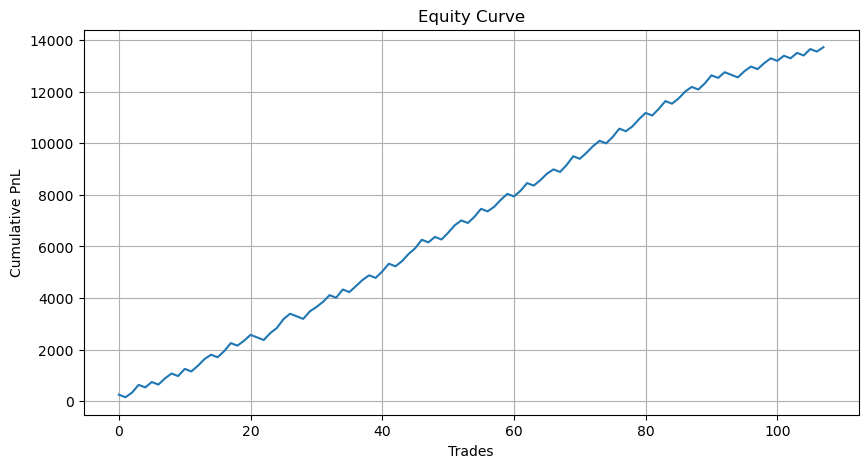

In [94]:
plt.figure(figsize = (10, 5))
plt.plot(df["cumulative_pnl"])
plt.title("Equity Curve")
plt.xlabel("Trades")
plt.ylabel("Cumulative PnL")
plt.grid(True)
plt.show()

In [95]:
X = df[["setup", "session", "emotion", "pair"]]
y = df["result"]

In [96]:
y = y.map({"loss" : 0, "win" : 1})

In [97]:
X = pd.get_dummies(X)

In [98]:
X.head()

,setup_Asia Breakout,setup_Liquidity Sweep,setup_NY Reversal,session_Asia,session_London,session_New York,emotion_calm,emotion_confident,emotion_fear,emotion_focused,emotion_revenge,emotion_tired,pair_ES,pair_NQ,pair_XAUUSD
0,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True
1,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
2,True,False,False,True,False,False,False,False,False,True,False,False,True,False,False
3,False,True,False,False,True,False,True,False,False,False,False,False,False,False,True
4,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False


In [99]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [100]:
X.head()

,setup_Asia Breakout,setup_Liquidity Sweep,setup_NY Reversal,session_Asia,session_London,session_New York,emotion_calm,emotion_confident,emotion_fear,emotion_focused,emotion_revenge,emotion_tired,pair_ES,pair_NQ,pair_XAUUSD
0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1
1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
2,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0
3,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1
4,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0


In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [102]:
from sklearn.linear_model import LogisticRegression

In [103]:
model = LogisticRegression()

In [104]:
model.fit(X_train, y_train)

LogisticRegression()

In [105]:
model.score(X_test, y_test)

0.9090909090909091

In [112]:
y_pred = model.predict(X_test)

In [136]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, y_pred)
log_accuracy

0.9090909090909091

In [137]:
import numpy as np
import seaborn as sn

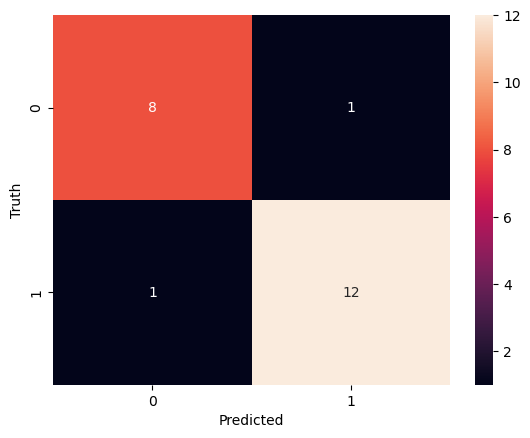

In [138]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

sn.heatmap(cm, annot=True)

plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

In [139]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89         9
           1       0.92      0.92      0.92        13

    accuracy                           0.91        22
   macro avg       0.91      0.91      0.91        22
weighted avg       0.91      0.91      0.91        22



In [140]:
from sklearn.ensemble import RandomForestClassifier

In [141]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

In [142]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [143]:
rf_model.score(X_test, y_test)

0.8636363636363636

In [144]:
rf_predictions = rf_model.predict(X_test)

In [145]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_accuracy

0.8636363636363636

In [146]:
print("Logistic Regression Accuracy:", log_accuracy)

print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.9090909090909091
Random Forest Accuracy: 0.8636363636363636


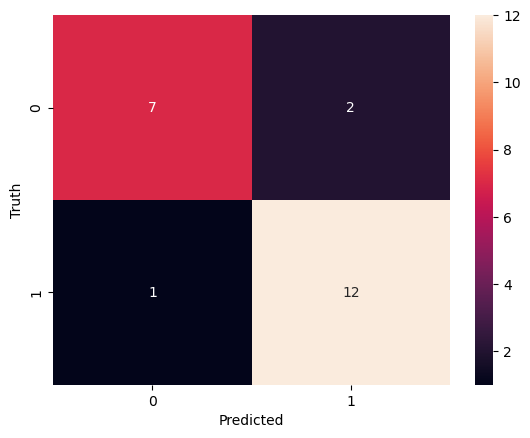

In [147]:
cm1 = confusion_matrix(y_test, rf_predictions)
sn.heatmap(cm1, annot=True)

plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

In [148]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.88      0.78      0.82         9
           1       0.86      0.92      0.89        13

    accuracy                           0.86        22
   macro avg       0.87      0.85      0.86        22
weighted avg       0.86      0.86      0.86        22



In [150]:
importance = rf_model.feature_importances_

In [151]:
feature_names = X.columns

In [156]:
feature_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})

In [157]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

                  Feature  Importance
8            emotion_fear    0.167330
10        emotion_revenge    0.108998
11          emotion_tired    0.108129
6            emotion_calm    0.106457
9         emotion_focused    0.089031
7       emotion_confident    0.088768
12                pair_ES    0.078005
14            pair_XAUUSD    0.066473
13                pair_NQ    0.046669
5        session_New York    0.028853
2       setup_NY Reversal    0.025289
4          session_London    0.023646
1   setup_Liquidity Sweep    0.021590
0     setup_Asia Breakout    0.020517
3            session_Asia    0.020246


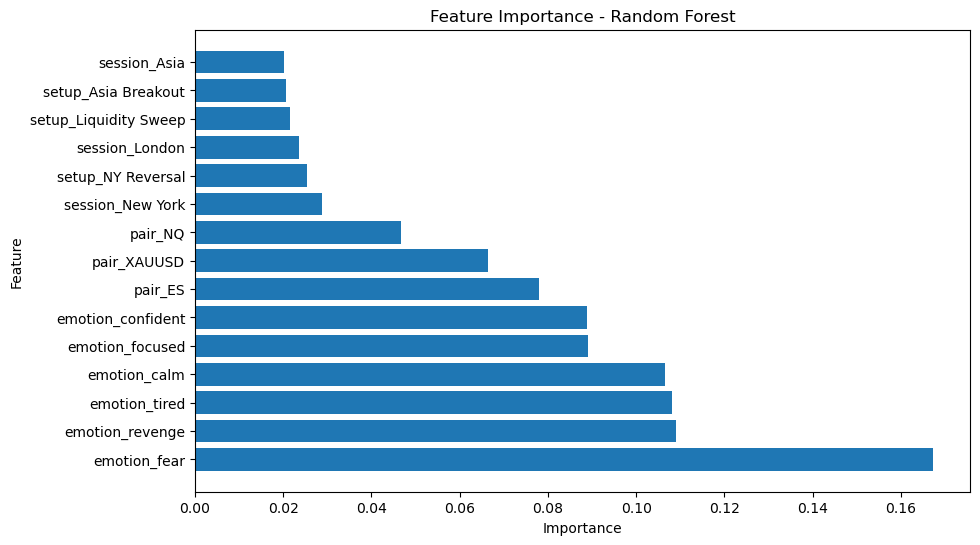

In [158]:
plt.figure(figsize = (10, 6))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

In [179]:
import joblib

In [180]:
joblib.dump(rf_model, "random_forest_model.pkl")

['random_forest_model.pkl']

In [181]:
joblib.dump(model, "logistic_model.pkl")

['logistic_model.pkl']

In [182]:
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']

In [183]:
import os
print(os.listdir())

['.anaconda', '.conda', '.condarc', '.continuum', '.copilot', '.insomniac', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.TurboVPN', '.virtual_documents', '.vscode', '.vscode-shared', 'AI_Trading_Journal.ipynb', 'Anaconda Scripts', 'anaconda3', 'anaconda_projects', 'ansel', 'AppData', 'Application Data', 'Bagging.ipynb', 'Contacts', 'Cookies', 'diabetes.csv', 'Documents', 'Downloads', 'Favorites', 'Hyper_Parameter_Tuning.ipynb', 'Income.csv', 'Jupyter_ML', 'KNN.ipynb', 'K_Fold_Cross_Validation.ipynb', 'Links', 'Local Settings', 'logistic_model.pkl', 'Melbourne_HP.csv', 'model_columns.pkl', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{ee4c93e8-8b16-11ef-b467-92471e518111}.TM.blf', 'NTUSER.DAT{ee4c93e8-8b16-11ef-b467-92471e518111}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{ee4c93e8-8b16-11ef-b467-92471e518111}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Packages', 'PCA.ipyn

In [184]:
loaded_model = joblib.load("random_forest_model.pkl")

In [185]:
type(loaded_model)

sklearn.ensemble._forest.RandomForestClassifier

In [186]:
model_columns = joblib.load("model_columns.pkl")

In [187]:
type(model_columns)

pandas.core.indexes.base.Index

In [188]:
print(model_columns)

Index(['setup_Asia Breakout', 'setup_Liquidity Sweep', 'setup_NY Reversal',
       'session_Asia', 'session_London', 'session_New York', 'emotion_calm',
       'emotion_confident', 'emotion_fear', 'emotion_focused',
       'emotion_revenge', 'emotion_tired', 'pair_ES', 'pair_NQ',
       'pair_XAUUSD'],
      dtype='object')


In [189]:
new_trade = pd.DataFrame({
    "setup": ["Liquidity Sweep"],
    "session": ["London"],
    "emotion": ["confident"],
    "pair": ["XAUUSD"]
})


In [190]:
new_trade_encoded = pd.get_dummies(new_trade)

In [191]:
new_trade_encoded = new_trade_encoded.reindex(columns = model_columns, fill_value = 0)

In [192]:
prediction = model.predict(new_trade_encoded)

In [193]:
prediction

array([1])

In [194]:
probability = model.predict_proba(new_trade_encoded)
probability

array([[0.16397977, 0.83602023]])

In [195]:
prediction = model.predict(new_trade_encoded)[0]
probability = model.predict_proba(new_trade_encoded)[0]
print("Prediction:", "WIN" if prediction == 1 else "LOSS")
print("Win Probability:", round(probability[1] * 100, 2), "%")

Prediction: WIN
Win Probability: 83.6 %
